# Day 1 — Manual filters

Apply simple kernels to images and treat the outputs as beginner-friendly feature maps.


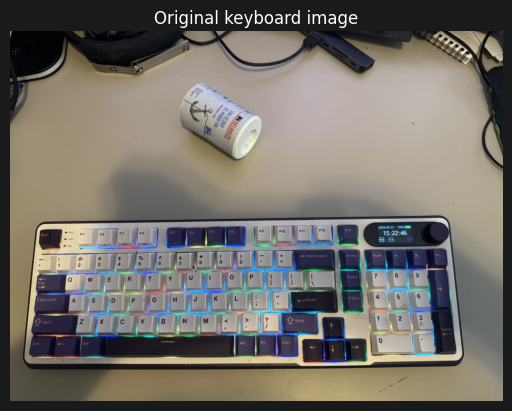

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image

image_path = Path("../data/my_sample_image.jpg")
image = Image.open(image_path).convert("RGB")

plt.imshow(image)
plt.axis("off")
plt.title("Original keyboard image")
plt.show()

In [3]:
import numpy as np

image_array = np.array(image)

image_array.shape, image_array.dtype, image_array.min(), image_array.max()

((4284, 5712, 3), dtype('uint8'), np.uint8(0), np.uint8(255))

## What the image shape means

The image array has shape `(4284, 5712, 3)`.

- `4284` = the image height: 4,284 rows of pixels.
- `5712` = the image width: 5,712 columns of pixels.
- `3` = the RGB color channels: red, green, and blue values for each pixel.
- `dtype("uint8")` means each color value is an unsigned 8-bit whole number, usually from `0` to `255`.
- `0` is the darkest channel value found in this image, and `255` is the brightest channel value found.

For this lab, the important idea is: filters do not see "keyboard" as a word or object. They scan pixel numbers and respond to local patterns like keycap edges, gaps, shadows, and outlines.


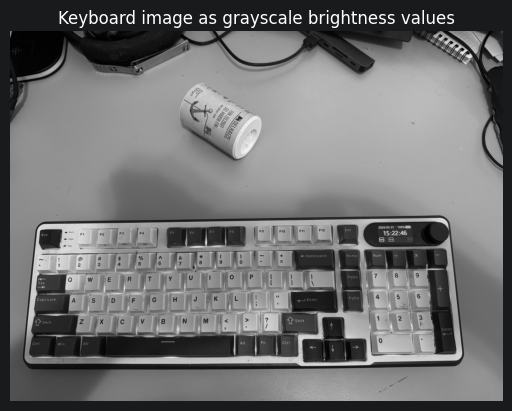

((4284, 5712), dtype('uint8'), np.uint8(0), np.uint8(255))

In [4]:
gray_image = image.convert("L")
gray_array = np.array(gray_image)

plt.imshow(gray_array, cmap="gray")
plt.axis("off")
plt.title("Keyboard image as grayscale brightness values")
plt.show()

gray_array.shape, gray_array.dtype, gray_array.min(), gray_array.max()

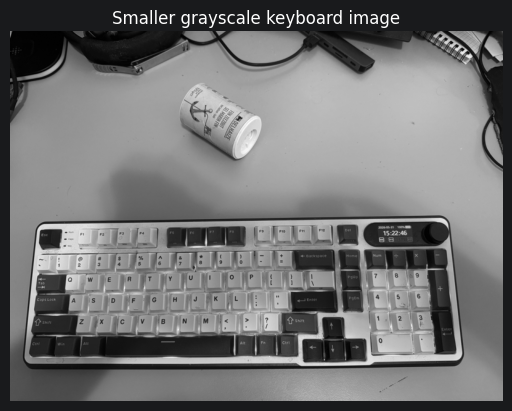

(600, 800)

In [5]:
max_width = 800
scale = max_width / gray_image.width
new_height = round(gray_image.height * scale)

small_gray_image = gray_image.resize((max_width, new_height))
small_gray_array = np.array(small_gray_image)

plt.imshow(small_gray_array, cmap="gray")
plt.axis("off")
plt.title("Smaller grayscale keyboard image")
plt.show()

small_gray_array.shape

## What is a feature map?

In this notebook, a **feature map** is the new grid of values created after applying one kernel across the image.

The process is:

1. Start with the image as a 2D brightness grid.
2. Place the kernel over a small patch, usually centered on one image location.
3. Multiply the patch values by the matching kernel values and add the results.
4. Store that one result in the output grid at the matching location.
5. Slide to the next center location and repeat.

So your understanding is right: the feature map is the collection of response values obtained by applying the kernel around each center position in the image.

Important distinction:

```text
original image pixel = brightness at that location
feature map value    = how strongly the kernel pattern appeared near that location
```

One kernel creates one feature map. Different kernels create different feature maps from the same input image. We display those response grids as images because it helps us inspect where the pattern appeared.


## Manual left-right edge filter

This 3x3 kernel is a small grid of weights. A weight multiplies the matching pixel brightness in the current image patch.

- `-1` subtracts brightness from the left side of the patch.
- `0` ignores the middle column.
- `1` adds brightness from the right side of the patch.

The result is large when the left and right sides have very different brightness values, which often happens at vertical key edges and gaps.


In [6]:
import numpy as np

# Compare right-side brightness with left-side brightness in each 3x3 image patch.
# Positive values mean the right side is brighter; negative values mean the left side is brighter.
edge_kernel = np.array(
    [
        [-1, 0, 1],
        [-1, 0, 1],
        [-1, 0, 1],
    ]
)

## Apply the filter with `correlate2d`

`correlate2d` slides the kernel across the 2D grayscale image. At each location, it lines the kernel up with a nearby image patch, multiplies matching values, and adds the results.

That one result becomes one value in `edge_response`. For example, `edge_response[y, x]` means: "how strongly did this kernel respond to the patch near row `y`, column `x`?"

The output, `edge_response`, is a feature map. Strong positive or negative values mean the filter found a strong left-right brightness change near that location. Values near zero mean the nearby brightness values were similar.


## Tiny 2D example: how an edge map is built

A filter does not copy image patches into the output. It writes **one response number** for each patch position. Those response numbers form the new image, or feature map.

Input brightness grid with a vertical dark-to-bright change:

```text
10   10   10   200  200
10   10   10   200  200
10   10   10   200  200
10   10   10   200  200
10   10   10   200  200
```

Left-right edge kernel:

```text
-1   0   1
-1   0   1
-1   0   1
```

This kernel computes:

```text
sum(right column brightness) - sum(left column brightness)
```

A flat dark patch gives a near-zero response:

```text
10   10   10
10   10   10   ->   (10 + 10 + 10) - (10 + 10 + 10) = 0
10   10   10
```

A patch crossing the dark-to-bright edge gives a strong response:

```text
10   10   200
10   10   200   ->   (200 + 200 + 200) - (10 + 10 + 10) = 570
10   10   200
```

Ignoring borders for simplicity, the output feature map is the grid of those responses:

```text
0    570  570
0    570  570
0    570  570
```

Placed under the matching center positions, the responses line up with the edge region:

```text
input positions:           output responses:

10  10  10  200 200        .    .    .    .    .
10  10  10  200 200        .    0   570  570   .
10  10  10  200 200   ->   .    0   570  570   .
10  10  10  200 200        .    0   570  570   .
10  10  10  200 200        .    .    .    .    .
```

The `570` values are **filter responses**, not original brightness values. If displayed as an image, large response values appear bright, so the edge region becomes visible as a bright vertical band.


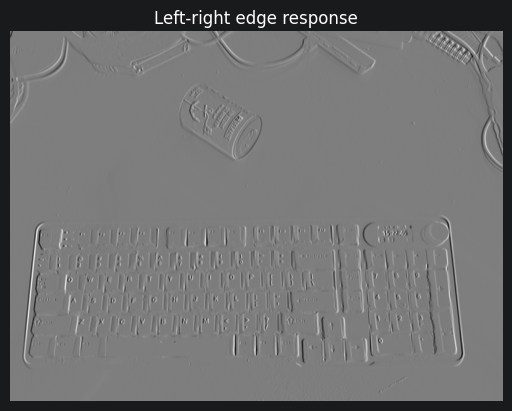

((600, 800), np.float64(-574.0), np.float64(587.0))

In [7]:
from scipy.signal import correlate2d

# Slide the edge kernel over the smaller grayscale image.
# mode="same" keeps the output the same height and width as the input image.
# boundary="symm" mirrors pixels at the border so edge pixels can still be processed.
edge_response = correlate2d(
    small_gray_array.astype(float),
    edge_kernel,
    mode="same",
    boundary="symm",
)

plt.imshow(edge_response, cmap="gray")
plt.axis("off")
plt.title("Left-right edge response")
plt.show()

edge_response.shape, edge_response.min(), edge_response.max()

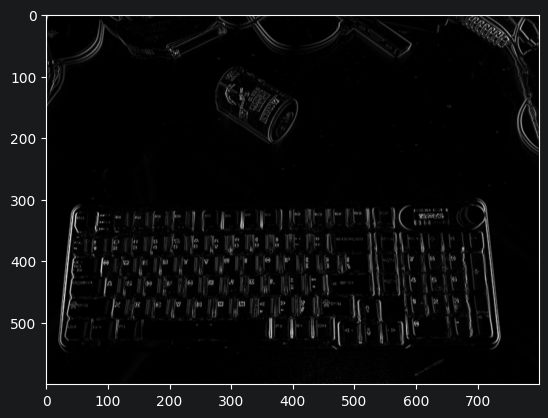

In [8]:
plt.imshow(np.abs(edge_response), cmap="gray")

## Read the edge map

The signed edge response keeps direction: positive means brightness increased left-to-right, and negative means brightness decreased left-to-right.

`np.abs(edge_response)` shows edge strength only. It keeps how strong the brightness change was, but it throws away which direction the brightness changed.


## Compare edge directions

Changing the kernel changes which brightness change becomes strong in the response map.

- The first kernel compares **left vs right** brightness, so it tends to make **vertical-looking edges** stronger.
- This second kernel compares **top vs bottom** brightness, so it tends to make **horizontal-looking edges** stronger.

The wording can feel backwards at first: a top-bottom brightness change often appears as a horizontal line, because the boundary runs left-to-right across the image.

For the keyboard image, compare which map emphasizes key sides, row boundaries, gaps, letters, and shadows. The point is not to label every line perfectly; the point is to notice that each kernel creates a different feature map from the same input image.


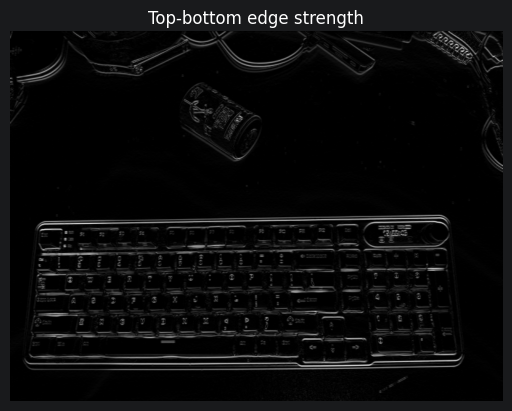

In [9]:
# Compare bottom-side brightness with top-side brightness in each 3x3 image patch.
# Strong responses often appear along horizontal-looking boundaries.
vertical_change_kernel = np.array(
    [
        [-1, -1, -1],
        [0, 0, 0],
        [1, 1, 1],
    ]
)

vertical_change_response = correlate2d(
    small_gray_array.astype(float),
    vertical_change_kernel,
    mode="same",
    boundary="symm",
)

plt.imshow(np.abs(vertical_change_response), cmap="gray")
plt.axis("off")
plt.title("Top-bottom edge strength")
plt.show()

## Compare the two edge feature maps side by side

This plot puts the two edge-strength maps next to each other so the orientation difference is easier to inspect.

- `np.abs(edge_response)` shows the strength of left-right brightness changes, which often appear as vertical-looking edges.
- `np.abs(vertical_change_response)` shows the strength of top-bottom brightness changes, which often appear as horizontal-looking edges.

Both images are feature maps: each bright location means that kernel found its pattern strongly nearby.


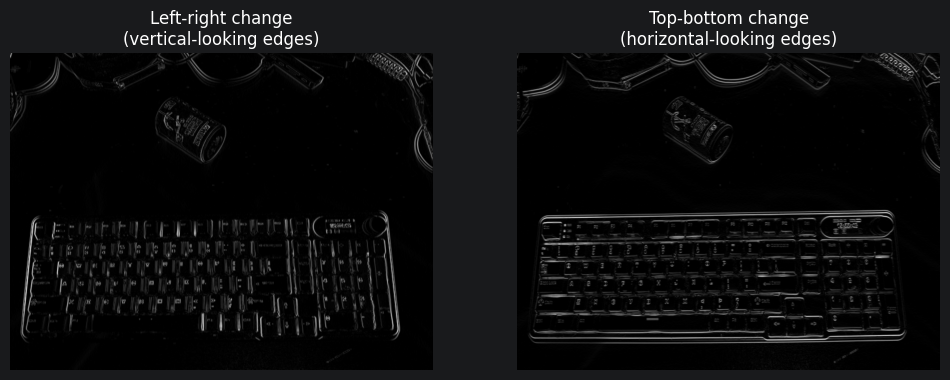

In [10]:
# Plot the two edge feature maps together for visual comparison.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(np.abs(edge_response), cmap="gray")
axes[0].set_title("Left-right change\n(vertical-looking edges)")
axes[0].axis("off")

axes[1].imshow(np.abs(vertical_change_response), cmap="gray")
axes[1].set_title("Top-bottom change\n(horizontal-looking edges)")
axes[1].axis("off")

plt.show()

## Blur kernel: average nearby brightness values

The blur kernel used here has thirty-six equal positive weights, so each output pixel becomes the average of a 6x6 neighborhood.

Dividing by `36` matters because there are thirty-six values in the kernel. Without that division, a flat patch of brightness `100` would become `3600`; with `/ 36`, it stays `100`. The division keeps the normal brightness scale; it is not what makes the blur stronger.

Averaging creates blur because it turns sharp jumps into gradual ramps. For a small one-dimensional example, an edge like:

```text
0   0   0   255 255 255
```

can become smoother after local averaging because middle values appear near the boundary:

```text
0   0   85   170   255  255
```

The edge looks softer because the direct jump from dark to bright has been spread across several positions. In 2D, the same idea happens with a patch: bright neighbors pull dark pixels brighter, and dark neighbors pull bright pixels darker.

A 6x6 blur is more visible than a 3x3 blur because it mixes a wider neighborhood. An even larger averaging kernel, such as 15x15, would mix an even wider area and create a stronger blur.

Blur does not find edges. It smooths tiny local differences, so small details and sharp transitions become softer.


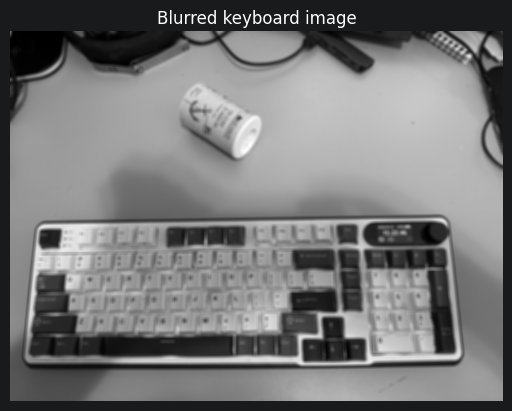

In [27]:
# The 6x6 average softens sharp changes by mixing each pixel with more neighbors.
# /36 keeps a flat patch at the same brightness instead of turning an average into a large sum.
blur_kernel = (
    np.array(
        [
            [1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1],
            [1, 1, 1, 1, 1, 1],
        ]
    )
    / 36
)

blurred = correlate2d(
    small_gray_array.astype(float),
    blur_kernel,
    mode="same",
    boundary="symm",
)

plt.imshow(blurred, cmap="gray")
plt.axis("off")
plt.title("Blurred keyboard image")
plt.show()

## Sharpen kernel: strengthen local contrast

The sharpen kernel keeps the center pixel strong and subtracts some brightness from the up, down, left, and right neighbors.

Flat areas stay fairly similar because the center and neighbor values mostly cancel in a balanced way. Edges, letters, shadows, and other local changes can become more noticeable because the center differs from its neighbors.

`np.clip(sharpened, 0, 255)` keeps the displayed image inside the usual grayscale range, where `0` is dark and `255` is bright.


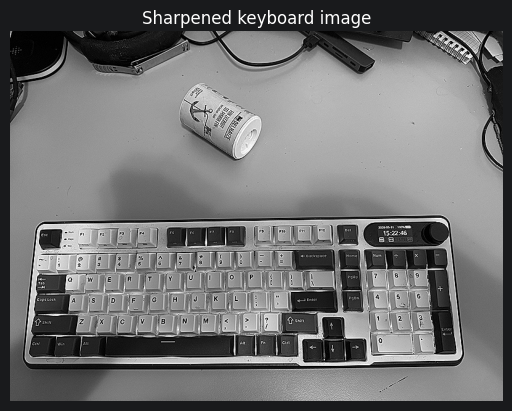

In [17]:
# Keep the center pixel strong while subtracting nearby neighbors to emphasize local contrast.
sharpen_kernel = np.array(
    [
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0],
    ]
)

sharpened = correlate2d(
    small_gray_array.astype(float),
    sharpen_kernel,
    mode="same",
    boundary="symm",
)

sharpened_display = np.clip(sharpened, 0, 255)

plt.imshow(sharpened_display, cmap="gray", vmin=0, vmax=255)
plt.axis("off")
plt.title("Sharpened keyboard image")
plt.show()

## Feature-map grid for inspection

This grid is the main visual evidence for Day 1. It shows the same keyboard image represented three ways:

- the original grayscale brightness grid,
- the left-right edge feature map,
- the top-bottom edge feature map.

The two edge maps are not original pixel brightness images. They are response maps: each displayed value comes from applying a kernel to a nearby patch and storing the result at the matching location.

Bright regions mean the matching filter found a strong brightness change nearby. Darker regions mean that filter found little of its pattern there.


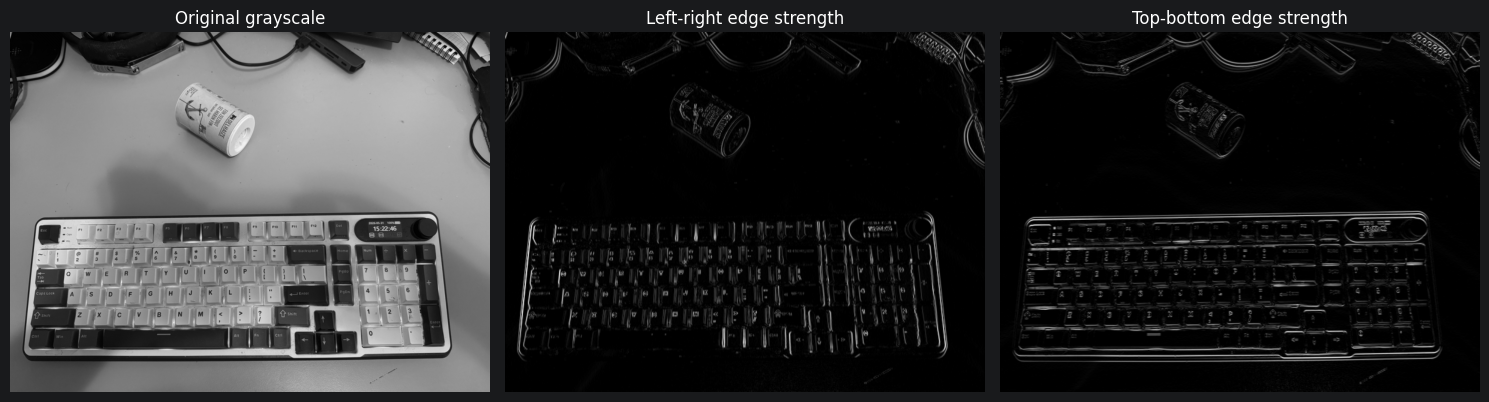

In [23]:
# Build the Day 1 inspection grid: original image plus two feature maps.
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(small_gray_array, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("Original grayscale")
axes[0].axis("off")

axes[1].imshow(np.abs(edge_response), cmap="gray")
axes[1].set_title("Left-right edge strength")
axes[1].axis("off")

axes[2].imshow(np.abs(vertical_change_response), cmap="gray")
axes[2].set_title("Top-bottom edge strength")
axes[2].axis("off")

plt.tight_layout()

output_dir = Path("../outputs/day01_manual_filters")
output_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(output_dir / "keyboard_manual_filter_grid.png", dpi=150, bbox_inches="tight")
plt.show()

## Controlled kernel tweak

To see that kernel values control the feature map, change one value in the left-right edge kernel and compare the response map before and after.

Here, one right-side weight changes from `1` to `2`. That gives extra importance to brightness on the right side of the 3x3 patch, so some left-right edge responses can become stronger.


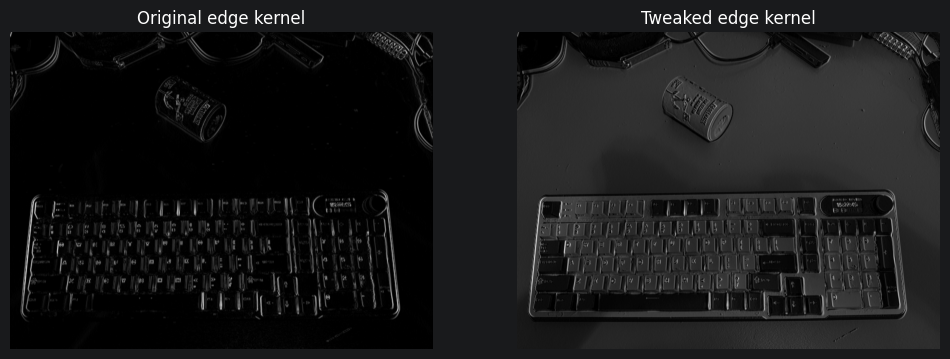

In [26]:
tweaked_edge_kernel = np.array(
    [
        [-1, 0, 1],
        [-1, 0, 2],  # changed this one value from 1 to 2
        [-1, 0, 1],
    ]
)

tweaked_edge_response = correlate2d(
    small_gray_array.astype(float),
    tweaked_edge_kernel,
    mode="same",
    boundary="symm",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(np.abs(edge_response), cmap="gray")
axes[0].set_title("Original edge kernel")
axes[0].axis("off")

axes[1].imshow(np.abs(tweaked_edge_response), cmap="gray")
axes[1].set_title("Tweaked edge kernel")
axes[1].axis("off")

plt.show()

## Reflection

I inspected a keyboard image using manual filters. The left-right edge feature map made vertical-looking boundaries stronger, especially around key sides and gaps. The top-bottom edge feature map emphasized more horizontal-looking boundaries, such as key row edges. I learned that a feature map is not the original image; it is a new grid of response values obtained by applying a kernel around each center position in the image. Each value says how strongly that kernel pattern appeared near that location. I also tweaked one right-side edge-kernel value from `1` to `2`; the map still showed similar vertical-looking boundaries, but some responses became stronger because the filter gave more weight to brightness on the right side of each patch.
